# Assignment 4: Final Project

## Setup

In [1]:
import open3d as o3d
from enum import Enum
from pyglm import glm
import numpy as np
from matplotlib import pyplot as plt
import slangpy as spy
from tqdm.notebook import tqdm
from time import time
import warnings
from PIL import Image


from cs248a_renderer import setup_device, RendererModules
from cs248a_renderer.model.bvh import BVH
from cs248a_renderer.model.transforms import Transform3D
from cs248a_renderer.model.material import PhysicsBasedMaterial, MaterialField, BRDFType
from cs248a_renderer.model.scene import Scene
from cs248a_renderer.model.mesh import Mesh
from cs248a_renderer.model.output import LPE, LPEEvent, LPEState, RayType, ScatterType
from cs248a_renderer.renderer.core_renderer import Renderer
from cs248a_renderer.model.lights import PointLight, DirectionalLight, RectangularLight
from cs248a_renderer.view_model.scene_manager import SceneManager

objc[29505]: Class GLFWHelper is implemented in both /Users/milner/Documents/VSCode/CS248A/asst4/.venv/lib/python3.12/site-packages/open3d/cpu/pybind.cpython-312-darwin.so (0x12780fa28) and /Users/milner/Documents/VSCode/CS248A/asst4/.venv/lib/python3.12/site-packages/slangpy/libsgl.dylib (0x17ccd12e8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[29505]: Class GLFWApplicationDelegate is implemented in both /Users/milner/Documents/VSCode/CS248A/asst4/.venv/lib/python3.12/site-packages/open3d/cpu/pybind.cpython-312-darwin.so (0x12780fa78) and /Users/milner/Documents/VSCode/CS248A/asst4/.venv/lib/python3.12/site-packages/slangpy/libsgl.dylib (0x17ccd1338). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[29505]: Class GLFWWindowDelegate is implemented in both /Users/milner/Documents/VSCode/CS248A/asst4/.venv/lib/python3.12/site-packages/open3d/

In [2]:
# Setup SlangPy device
device = setup_device([])
renderer_modules = RendererModules(device)

# OUTPUT_IMG_SIZE = (512, 512)
# output_image = device.create_texture(
#     type=spy.TextureType.texture_2d,
#     format=spy.Format.rgba32_float,
#     usage=spy.TextureUsage.unordered_access,
#     width=OUTPUT_IMG_SIZE[0],
#     height=OUTPUT_IMG_SIZE[1],
# )

# renderer = Renderer(
#     device=device,
#     render_texture=output_image,
#     render_modules=renderer_modules
# )

[INFO] (rhi) layer: CreateDevice: Debug layer is enabled.
[WARN] No supported shader model found, pretending to support sm_6_0.


In [3]:
def tone_mapping(image_np, gamma=2.2, exposure_time=1.0):
    gamma_corrected_image = np.power(image_np[:, :, :3] * exposure_time, 1.0 / gamma)
    return np.clip(gamma_corrected_image, 0.0, 1.0)


In [4]:
def build_bvh(scene):
    MAX_NODES = 8192
    triangles, materials = scene.extract_triangles_with_material()
    tqdm_bar = tqdm(total=MAX_NODES)
    def on_progress(current: int, total: int) -> None:
        tqdm_bar.n = current
        tqdm_bar.refresh()
    bvh = BVH(
        primitives=triangles,
        max_nodes=MAX_NODES,
        min_prim_per_node=4,
        on_progress=on_progress
    )

    return bvh, triangles, materials

In [5]:
# Scene Definition
class LightType(Enum):
    FLASH = "flash"
    POINT_LIGHT_AT_CAMERA = "point_at_camera"
    POINT_LIGHT_ON_THE_CEILING = "point_on_the_ceiling"
    DIRECTIONAL_LIGHT_INTO_THE_SCENE = "directional_into_the_scene"
    RECTANGULAR_LIGHT_ON_THE_CEILING = "rectangular_on_the_ceiling"
    RECTANGULAR_LIGHT_ON_THE_CEILING_DIMMER = "rectangular_on_the_ceiling_dimmer"

def getLight(light_type: LightType, light_transform: Transform3D, camera_position: glm.vec3):
    if light_type == LightType.FLASH:
        return None
    elif light_type == LightType.POINT_LIGHT_AT_CAMERA:
        return PointLight(position=camera_position, color=glm.vec3(1.0, 1.0, 1.0), intensity=1000.0)
    elif light_type == LightType.POINT_LIGHT_ON_THE_CEILING:
        return PointLight(transform=light_transform, position=glm.vec3(0.0), color=glm.vec3(1.0, 1.0, 1.0), intensity=500.0)
    elif light_type == LightType.DIRECTIONAL_LIGHT_INTO_THE_SCENE:
        return DirectionalLight(direction=glm.vec3(0.0, 0.0, -1.0), color=glm.vec3(1.0, 1.0, 1.0), intensity=5.0)
    elif light_type == LightType.RECTANGULAR_LIGHT_ON_THE_CEILING:
        return RectangularLight(
            transform=light_transform,
            vertices=[
                glm.vec3(-2.0, 0.0, -2.0),
                glm.vec3(2.0, 0.0, -2.0),
                glm.vec3(2.0, 0.0, 2.0),
                glm.vec3(-2.0, 0.0, 2.0)
            ],
            color=glm.vec3(1.0, 1.0, 1.0),
            intensity=10.0,
            doubleSided=False
        )
    elif light_type == LightType.RECTANGULAR_LIGHT_ON_THE_CEILING_DIMMER:
        return RectangularLight(
            transform=light_transform,
            vertices=[
                glm.vec3(-2.0, 0.0, -2.0),
                glm.vec3(2.0, 0.0, -2.0),
                glm.vec3(2.0, 0.0, 2.0),
                glm.vec3(-2.0, 0.0, 2.0)
            ],
            color=glm.vec3(1.0, 1.0, 1.0),
            intensity=5.0,
            doubleSided=False
        )

class CornellBoxMode(Enum):
    SIMPLE = "simple"
    SHADOW = "SHADOW"
    MIRROR_OBJECTS = "mirror_objects"
    DEFAULT_CORNELL_BOX = "default_cornell_box"
    GLASS_BALL = "glass_ball"

# We'll load the Stanford bunny model into our scene.
def get_cornell_box(mode: CornellBoxMode = CornellBoxMode.SIMPLE, light_type: LightType = LightType.FLASH, ior: float = 1.5):
    object_names = ['floor', 'left_wall', 'right_wall', 'back_wall', 'ceiling', 'bunny1', 'bunny2', 'ball1']
    object2brdf_mapping = {k: BRDFType.LAMBERTIAN for k in object_names}

    if mode == CornellBoxMode.SIMPLE:
        if light_type != LightType.FLASH:
            warnings.warn(f"Overriding light_type: {light_type} with {LightType.FLASH} in Cornell Box Mode: {mode}")
        light_type = LightType.FLASH
    elif mode == CornellBoxMode.MIRROR_OBJECTS:
        object2brdf_mapping['bunny2'] = BRDFType.MIRROR
    elif mode == CornellBoxMode.DEFAULT_CORNELL_BOX:
        light_type = LightType.RECTANGULAR_LIGHT_ON_THE_CEILING
        object2brdf_mapping['bunny2'] = BRDFType.MIRROR
    elif mode == CornellBoxMode.GLASS_BALL:
        object2brdf_mapping['ball1'] = BRDFType.GLASS


    ######## Create Cornell Box ########
    scene = Scene()
    # Set camera position and orientation
    cam = scene.camera
    eye = glm.vec3(0.0, 5.0, 20.0)
    cam.transform.position = eye
    # quat using lookat
    target = glm.vec3(0.0, 5.0, 0.0)
    cam.transform.rotation = glm.quatLookAt(glm.normalize(target - eye), glm.vec3(0.0, 1.0, 0.0))


    # A White colored Floor plane
    o3d_plane = o3d.io.read_triangle_mesh("../../resources/plane.obj")
    floor_plane = Mesh(o3d_plane)
    floor_plane.transform.scale = glm.vec3(5.0, 5.0, 5.0)
    floor_plane.material = PhysicsBasedMaterial(albedo=MaterialField(uniform_value=glm.vec3(1.0, 1.0, 1.0)), brdf_type=object2brdf_mapping['floor'])
    scene.add_object(floor_plane)

    # A Red coloredLeft Wall
    left_wall = Mesh(o3d_plane)
    left_wall.transform.position = glm.vec3(-5.0, 5.0, 0.0)
    left_wall.transform.rotation = glm.angleAxis(glm.radians(-90.0), glm.vec3(0.0, 0.0, 1.0))
    left_wall.transform.scale = glm.vec3(5.0, 5.0, 5.0)
    left_wall.material = PhysicsBasedMaterial(albedo=MaterialField(uniform_value=glm.vec3(1.0, 0.0, 0.0)), brdf_type=object2brdf_mapping['left_wall'])
    scene.add_object(left_wall)

    # A Green colored Right Wall
    right_wall = Mesh(o3d_plane)
    right_wall.transform.position = glm.vec3(5.0, 5.0, 0.0)
    right_wall.transform.rotation = glm.angleAxis(glm.radians(90.0), glm.vec3(0.0, 0.0, 1.0))
    right_wall.transform.scale = glm.vec3(5.0, 5.0, 5.0)
    right_wall.material = PhysicsBasedMaterial(albedo=MaterialField(uniform_value=glm.vec3(0.0, 1.0, 0.0)), brdf_type=object2brdf_mapping['right_wall'])
    scene.add_object(right_wall)

    # A White colored Back Wall
    back_wall = Mesh(o3d_plane)
    back_wall.transform.position = glm.vec3(0.0, 5.0, -5.0)
    back_wall.transform.rotation = glm.angleAxis(glm.radians(90.0), glm.vec3(1.0, 0.0, 0.0))
    back_wall.transform.scale = glm.vec3(5.0, 5.0, 5.0)
    back_wall.material = PhysicsBasedMaterial(albedo=MaterialField(uniform_value=glm.vec3(1.0, 1.0, 1.0)), brdf_type=object2brdf_mapping['back_wall'])
    if mode == CornellBoxMode.GLASS_BALL:
        back_wall.material = PhysicsBasedMaterial(
            albedo=MaterialField(
                uniform_value=glm.vec3(1.0, 1.0, 1.0),
                use_texture=True,
                texture_map_path="../../resources/uv_grid.png"
            ),
            brdf_type=object2brdf_mapping['back_wall']
        )
    scene.add_object(back_wall)

    # A White colored Ceiling
    ceiling = Mesh(o3d_plane)
    ceiling.transform.position = glm.vec3(0.0, 10.0, 0.0)
    ceiling.transform.rotation = glm.angleAxis(glm.radians(180.0), glm.vec3(1.0, 0.0, 0.0))
    ceiling.transform.scale = glm.vec3(5.0, 5.0, 5.0)
    ceiling.material = PhysicsBasedMaterial(albedo=MaterialField(uniform_value=glm.vec3(1.0, 1.0, 1.0)), brdf_type=object2brdf_mapping['ceiling'])
    scene.add_object(ceiling)

    # Add Lights to the scene
    light_transform = Transform3D(
        position=glm.vec3(0.0, 9.99, 0.0),
        rotation=glm.angleAxis(glm.radians(0.0), glm.vec3(1.0, 0.0, 0.0)),
        scale=glm.vec3(1.0, 1.0, 1.0)
    )

    # Place two bunnies in the scene: One with Lambertian BRDF and the other with Mirror BRDF
    if mode != CornellBoxMode.GLASS_BALL:
        o3d_mesh = o3d.io.read_triangle_mesh("../../resources/bunny.obj")
        bunny1 = Mesh(o3d_mesh)
        bunny1.transform.position = glm.vec3(-2.0, 1.0, -2.0)
        bunny1.material = PhysicsBasedMaterial(albedo=MaterialField(uniform_value=glm.vec3(1.0, 1.0, 1.0)), brdf_type=object2brdf_mapping['bunny1'])
        scene.add_object(bunny1)

        bunny2 = Mesh(o3d_mesh)
        bunny2.transform.position = glm.vec3(2.0, 1.0, 2.0)
        bunny2.material = PhysicsBasedMaterial(albedo=MaterialField(uniform_value=glm.vec3(1.0, 1.0, 1.0)), brdf_type=object2brdf_mapping['bunny2'])
        scene.add_object(bunny2)
    else:
        # Place two bunnies in the scene: One with Lambertian BRDF and the other with Mirror BRDF
        o3d_mesh = o3d.io.read_triangle_mesh("../../resources/uv_sphere_smooth.obj")
        ball1 = Mesh(o3d_mesh)
        ball1.transform.position = glm.vec3(0.0, 5.0, 0.0)
        ball1.transform.scale = glm.vec3(2.0, 2.0, 2.0)
        ball1.material = PhysicsBasedMaterial(albedo=MaterialField(uniform_value=glm.vec3(1.0, 1.0, 1.0)), brdf_type=object2brdf_mapping['ball1'])
        ball1.material.ior = ior
        scene.add_object(ball1)

    light = getLight(light_type, light_transform, eye)
    if light is not None:
        scene.add_object(light)

    return scene

## Project

In [11]:
# Load in Scene
scene_manager = SceneManager()
scene_manager.deserialize_scene("../../resources/cbox2.zip")
scene = scene_manager.scene

bvh, triangles, materials = build_bvh(scene)

  0%|          | 0/8192 [00:00<?, ?it/s]

**Example 1:** Separate scene into standard LPE components and demonstrate how they add up to the original beauty pass.

In [16]:
OUTPUT_IMG_SIZE = (800, 600)

lpes = [
    LPE([ # direct diffuse
        LPEState(LPEEvent(RayType.Camera, ScatterType.Any), [1,2,0,0]),
        LPEState(LPEEvent(RayType.Reflection, ScatterType.Diffuse), [2,0,0,0]),
        LPEState(LPEEvent(RayType.Light, ScatterType.Any), isTerminal=True)
    ]),
    LPE([ # indirect diffuse
        LPEState(LPEEvent(RayType.Camera, ScatterType.Any), [1,0,0,0]),
        LPEState(LPEEvent(RayType.Reflection, ScatterType.Diffuse), [2,0,0,0]),
        LPEState(LPEEvent(RayType.Any, ScatterType.Any), [2,3,0,0]),
        LPEState(LPEEvent(RayType.Light, ScatterType.Any), isTerminal=True)
    ]),
    LPE([ # direct specular
        LPEState(LPEEvent(RayType.Camera, ScatterType.Any), [1,0,0,0]),
        LPEState(LPEEvent(RayType.Reflection, ScatterType.Specular), [2,0,0,0]),
        LPEState(LPEEvent(RayType.Light, ScatterType.Any), isTerminal=True)
    ]),
    LPE([ # indirect specular
        LPEState(LPEEvent(RayType.Camera, ScatterType.Any), [1,0,0,0]),
        LPEState(LPEEvent(RayType.Reflection, ScatterType.Specular), [2,0,0,0]),
        LPEState(LPEEvent(RayType.Any, ScatterType.Any), [2,3,0,0]),
        LPEState(LPEEvent(RayType.Light, ScatterType.Any), isTerminal=True)
    ]),
    LPE([ # transmission
        LPEState(LPEEvent(RayType.Camera, ScatterType.Any), [1,0,0,0]),
        LPEState(LPEEvent(RayType.Transmission, ScatterType.Specular), [2,3,0,0]),
        LPEState(LPEEvent(RayType.Any, ScatterType.Any), [2,3,0,0]),
        LPEState(LPEEvent(RayType.Light, ScatterType.Any), isTerminal=True)
    ]),
]

aovs = spy.InstanceBuffer(
    renderer_modules.output_module[f"Pixel<float4,{len(lpes)+1}>"].as_struct(), 
    (OUTPUT_IMG_SIZE[1], OUTPUT_IMG_SIZE[0]),
)

renderer = Renderer(
    device=device,
    render_texture=aovs,
    render_modules=renderer_modules,
)

renderer.load_bvh(triangles, bvh)
renderer.load_materials(materials)
renderer.load_lights(scene=scene)
renderer.build_lpes(lpes)

spp = 64
renderer.clear_render_target()
for i in tqdm(range(spp)):
    renderer.render_step(
        scene.camera.view_matrix(),
        scene.camera.fov,
        smooth_shading=True,
        path_trace_depth=4,
        use_cosine_weighted_sampling=True,
        fresnel_effect=True,
    )

example1 = aovs.to_numpy() \
        .view(dtype=np.float32) \
        .reshape((OUTPUT_IMG_SIZE[1], OUTPUT_IMG_SIZE[0], -1, 4)) \
        .transpose((2,0,1,3)).copy()

  0%|          | 0/64 [00:00<?, ?it/s]

The MSE between beauty and sum(LPEs): 1.0277629907814111e-15


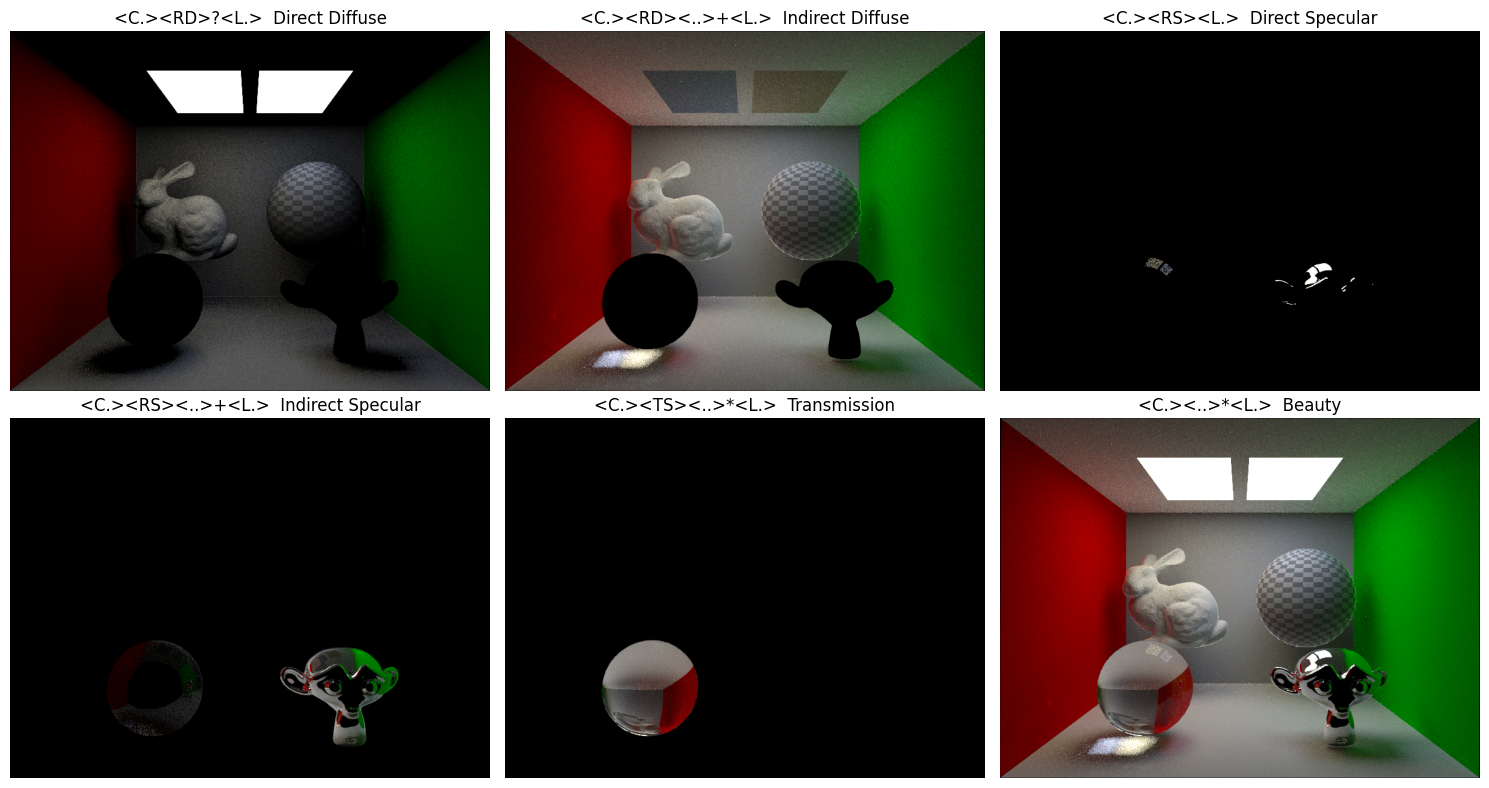

In [ ]:
# Check that AOVs properly add up
beauty = example1[-1]
sum = example1[0:-1].sum(0)
mse = np.mean(np.square(tone_mapping(sum) - tone_mapping(beauty)))
print(f"The MSE between beauty and sum(LPEs): {mse}")

# Display results
titles = [
    "<C.><RD>?<L.>  Direct Diffuse",
    "<C.><RD><..>+<L.>  Indirect Diffuse",
    "<C.><RS><L.>  Direct Specular",
    "<C.><RS><..>+<L.>  Indirect Specular",
    "<C.><TS><..>*<L.>  Transmission",
    "<C.><..>*<L.>  Beauty",
]
fig, axes = plt.subplots(2,3, figsize=(15, 8))
for i, axx in enumerate(axes):
    for j, ax in enumerate(axx):
        ax.imshow(np.clip(np.flipud(
            tone_mapping(example1[3*i+j], exposure_time=1.0)
        ), 0, 1))
        ax.set_title(titles[3*i+j])
        ax.axis('off')

plt.tight_layout()
plt.show()

**Example 2:** Separate scene by light, then perform a compositing-based relighting workflow

In [ ]:
OUTPUT_IMG_SIZE = (800, 600)

lpes = [
    LPE([ # light 0
        LPEState(LPEEvent(RayType.Camera, ScatterType.Any), [1,2,0,0]),
        LPEState(LPEEvent(RayType.Any, ScatterType.Any), [1,2,0,0]),
        LPEState(LPEEvent(RayType.Light, ScatterType.Any, lightTag=0), isTerminal=True)
    ]),
    LPE([ # light 1
        LPEState(LPEEvent(RayType.Camera, ScatterType.Any), [1,2,0,0]),
        LPEState(LPEEvent(RayType.Any, ScatterType.Any), [1,2,0,0]),
        LPEState(LPEEvent(RayType.Light, ScatterType.Any, lightTag=1), isTerminal=True)
    ]),
]

aovs = spy.InstanceBuffer(
    renderer_modules.output_module[f"Pixel<float4,{len(lpes)+1}>"].as_struct(), 
    (OUTPUT_IMG_SIZE[1], OUTPUT_IMG_SIZE[0]),
)

renderer = Renderer(
    device=device,
    render_texture=aovs,
    render_modules=renderer_modules,
)

renderer.load_bvh(triangles, bvh)
renderer.load_materials(materials)
renderer.load_lights(scene=scene)
renderer.build_lpes(lpes)

spp = 64
renderer.clear_render_target()
for i in tqdm(range(spp)):
    renderer.render_step(
        scene.camera.view_matrix(),
        scene.camera.fov,
        smooth_shading=True,
        path_trace_depth=4,
        use_cosine_weighted_sampling=True,
        fresnel_effect=True,
    )

example2 = aovs.to_numpy() \
        .view(dtype=np.float32) \
        .reshape((OUTPUT_IMG_SIZE[1], OUTPUT_IMG_SIZE[0], -1, 4)) \
        .transpose((2,0,1,3)).copy()

scene.rectangular_lights.

  0%|          | 0/64 [00:00<?, ?it/s]

[WARN] (rhi) slang: metal 32023.850: /Users/milner/Documents/VSCode/CS248A/asst4/src/cs248a_renderer/slang_shaders/./renderer/mesh_renderer.slang(38): warning :  unused variable '_S442' [-Wunused-variable]
        bool _S442 = LPEAutomaton_advance_0(&lpes_0[e_0], &_S441);
             ^
metal 32023.850: /Users/milner/Documents/VSCode/CS248A/asst4/src/cs248a_renderer/slang_shaders/./renderer/mesh_renderer.slang(205): warning :  unused variable '_S470' [-Wunused-variable]
                    bool _S470 = LPEAutomaton_advance_0(&lpes_0[e_0], &_S469);
                         ^
2 warnings generated.



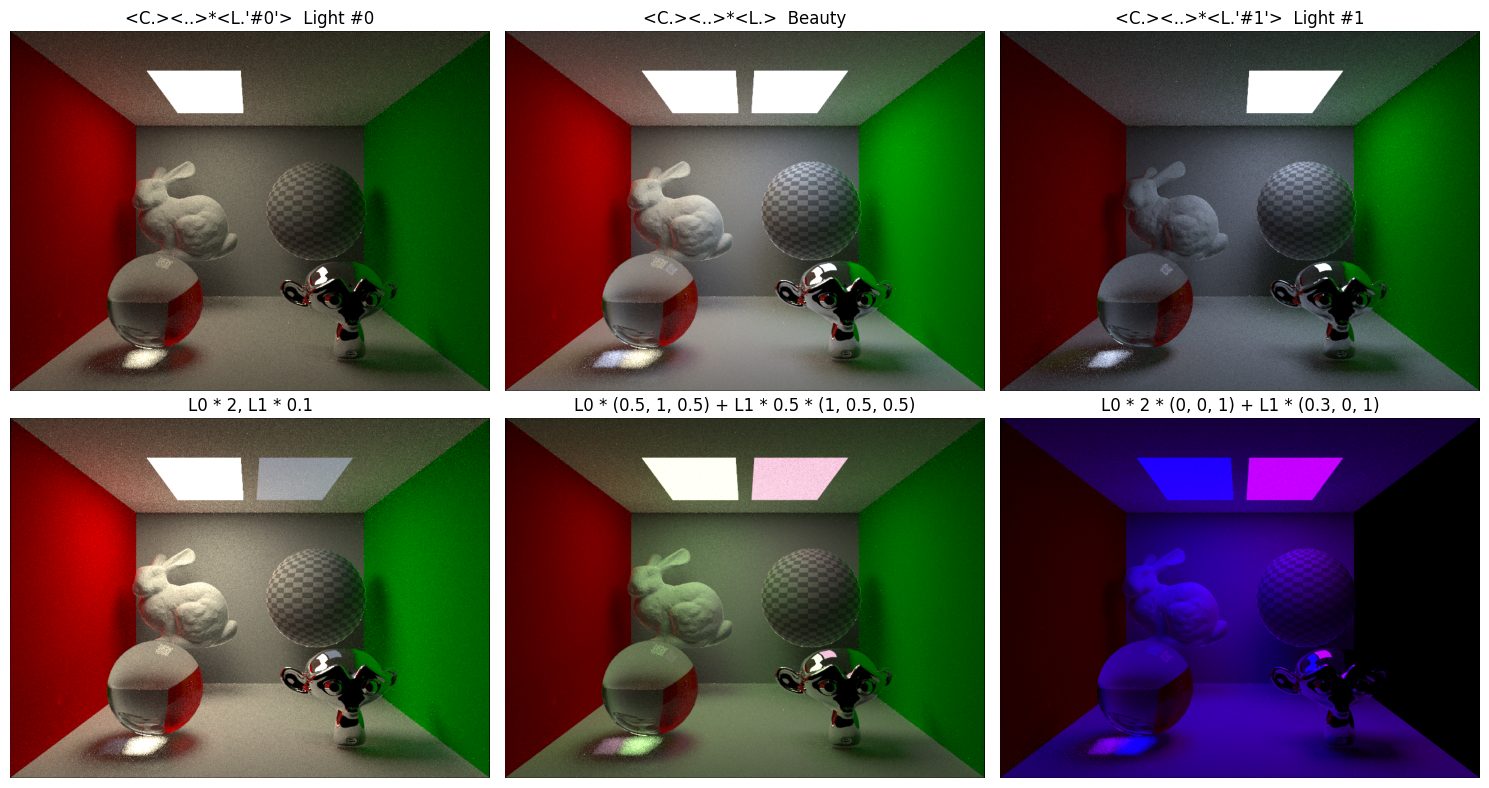

In [51]:
# Check that AOVs properly add up
beauty = example2[-1]
light0 = example2[0]
light1 = example2[1]

ex1 = light0 * 2 + light1 * 0.1
ex2 = light0 * np.array([0.5, 1.0, 0.5, 1.0]) + light1 * 0.5 * np.array([1.0, 0.5, 0.5, 1.0])
ex3 = light0 * 2 * np.array([0.0, 0.0, 1.0, 1.0]) + light1 * np.array([0.3, 0.0, 1.0, 1.0])

e2results = [light0, beauty, light1, ex1, ex2, ex3]

# Display results
titles = [
    "<C.><..>*<L.'#0'>  Light #0",
    "<C.><..>*<L.>  Beauty",
    "<C.><..>*<L.'#1'>  Light #1",
    "L0 * 2, L1 * 0.1",
    "L0 * (0.5, 1, 0.5) + L1 * 0.5 * (1, 0.5, 0.5)",
    "L0 * 2 * (0, 0, 1) + L1 * (0.3, 0, 1)"
]
fig, axes = plt.subplots(2,3, figsize=(15, 8))
for i, axx in enumerate(axes):
    for j, ax in enumerate(axx):
        ax.imshow(np.clip(np.flipud(
            tone_mapping(e2results[3*i+j], exposure_time=1.0)
        ), 0, 1))
        ax.set_title(titles[3*i+j])
        ax.axis('off')

plt.tight_layout()
plt.show()

**Benchmarks**

In [52]:
OUTPUT_IMG_SIZE = (800, 600)

lpes = [
    LPE([ # direct diffuse
        LPEState(LPEEvent(RayType.Camera, ScatterType.Any), [1,2,0,0]),
        LPEState(LPEEvent(RayType.Reflection, ScatterType.Diffuse), [2,0,0,0]),
        LPEState(LPEEvent(RayType.Light, ScatterType.Any), isTerminal=True)
    ]),
    LPE([ # indirect diffuse
        LPEState(LPEEvent(RayType.Camera, ScatterType.Any), [1,0,0,0]),
        LPEState(LPEEvent(RayType.Reflection, ScatterType.Diffuse), [2,0,0,0]),
        LPEState(LPEEvent(RayType.Any, ScatterType.Any), [2,3,0,0]),
        LPEState(LPEEvent(RayType.Light, ScatterType.Any), isTerminal=True)
    ]),
    LPE([ # direct specular
        LPEState(LPEEvent(RayType.Camera, ScatterType.Any), [1,0,0,0]),
        LPEState(LPEEvent(RayType.Reflection, ScatterType.Specular), [2,0,0,0]),
        LPEState(LPEEvent(RayType.Light, ScatterType.Any), isTerminal=True)
    ]),
    LPE([ # indirect specular
        LPEState(LPEEvent(RayType.Camera, ScatterType.Any), [1,0,0,0]),
        LPEState(LPEEvent(RayType.Reflection, ScatterType.Specular), [2,0,0,0]),
        LPEState(LPEEvent(RayType.Any, ScatterType.Any), [2,3,0,0]),
        LPEState(LPEEvent(RayType.Light, ScatterType.Any), isTerminal=True)
    ]),
    LPE([ # transmission
        LPEState(LPEEvent(RayType.Camera, ScatterType.Any), [1,0,0,0]),
        LPEState(LPEEvent(RayType.Transmission, ScatterType.Specular), [2,3,0,0]),
        LPEState(LPEEvent(RayType.Any, ScatterType.Any), [2,3,0,0]),
        LPEState(LPEEvent(RayType.Light, ScatterType.Any), isTerminal=True)
    ]),
]

aovs = spy.InstanceBuffer(
    renderer_modules.output_module[f"Pixel<float4,{len(lpes)+1}>"].as_struct(), 
    (OUTPUT_IMG_SIZE[1], OUTPUT_IMG_SIZE[0]),
)

renderer = Renderer(
    device=device,
    render_texture=aovs,
    render_modules=renderer_modules,
)

renderer.load_bvh(triangles, bvh)
renderer.load_materials(materials)
renderer.load_lights(scene=scene)
renderer.build_lpes(lpes)

import time


lpe_times = []

spp = 64
for r in tqdm(range(5)):
    renderer.clear_render_target()
    start = time.perf_counter()
    for i in tqdm(range(spp)):
        renderer.render_step(
            scene.camera.view_matrix(),
            scene.camera.fov,
            smooth_shading=True,
            path_trace_depth=4,
            use_cosine_weighted_sampling=True,
            fresnel_effect=True,
        )
    end = time.perf_counter()
    lpe_times.append(end - start)

print(lpe_times)

lpes = []
aovs = spy.InstanceBuffer(
    renderer_modules.output_module[f"Pixel<float4,{len(lpes)+1}>"].as_struct(), 
    (OUTPUT_IMG_SIZE[1], OUTPUT_IMG_SIZE[0]),
)

renderer = Renderer(
    device=device,
    render_texture=aovs,
    render_modules=renderer_modules,
)

renderer.load_bvh(triangles, bvh)
renderer.load_materials(materials)
renderer.load_lights(scene=scene)
renderer.build_lpes(lpes)

no_lpe_times = []

for r in tqdm(range(5)):
    renderer.clear_render_target()
    start = time.perf_counter()
    for i in tqdm(range(spp)):
        renderer.render_step(
            scene.camera.view_matrix(),
            scene.camera.fov,
            smooth_shading=True,
            path_trace_depth=4,
            use_cosine_weighted_sampling=True,
            fresnel_effect=True,
        )
    end = time.perf_counter()
    no_lpe_times.append(end - start)

print(no_lpe_times)


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

...

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

[7.066714333835989, 6.0145770001690835, 5.940644458169118, 5.950138209154829, 5.959169041132554]


In [ ]:
lpes = [
    LPE([ # caustics
        LPEState(LPEEvent(RayType.Camera, ScatterType.Any), [1,0,0,0]),
        LPEState(LPEEvent(RayType.Any, ScatterType.Diffuse), [2,0,0,0]),
        LPEState(LPEEvent(RayType.Any, ScatterType.Specular), [2,3,0,0]),
        LPEState(LPEEvent(RayType.Light, ScatterType.Any), isTerminal=True)
    ]),
    LPE([ # emissive
        LPEState(LPEEvent(RayType.Camera, ScatterType.Any), [1,0,0,0]),
        LPEState(LPEEvent(RayType.Light, ScatterType.Any), isTerminal=True)
    ]),
]

# Save the rendered image
# image = Image.fromarray((np.clip(np.flipud(tone_mapping(output_image.to_numpy(), exposure_time=1.0)), 0, 1) * 255).astype(np.uint8))
# image.save("cornell_box_render.png")